<a href="https://colab.research.google.com/github/Ayseatci/DI725_Assignment1/blob/dev/notebooks/Hybrid_RoBERTa_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone -b dev https://github.com/Ayseatci/DI725_Assignment1.git

fatal: destination path 'DI725_Assignment1' already exists and is not an empty directory.


In [3]:
%cd DI725_Assignment1

/content/DI725_Assignment1


In [4]:
!pip install wandb
!wandb login
import wandb

wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter: 
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: ayseatci00 (ayseatci00-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Oversampling and categorical features

In [5]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer
)

# Initialize W&B
PROJECT_NAME = "DI725_Assignment_1"
EXPERIMENT_NAME = "hybrid-roberta-tail-mult4-categorical"

SEED = 42

def set_seed(seed=42):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"Global seed set to: {seed}")

set_seed(SEED)

wandb.init(
    project=PROJECT_NAME,
    name=EXPERIMENT_NAME,
    config={
        "learning_rate": 2e-5,
        "epochs": 5,
        "batch_size": 8,
        "oversampling": "4x_minority",
        "model_type": "hybrid_roberta_categorical",
        "truncation": "tail",
        "seed": SEED
    }
)

# Data Loading
train_df = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df = pd.read_csv("data/preprocessed/preprocessed_val.csv")

def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels", "issue_area", "issue_category"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label", "issue_area", "issue_category"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df

train_df = normalize_label_column(train_df)
val_df = normalize_label_column(val_df)

train_df["labels"] = train_df["labels"].astype(int)
val_df["labels"] = val_df["labels"].astype(int)

# 4x Oversampling
counts = train_df["labels"].value_counts()
min_class = counts.idxmin()
min_size = counts.min()
max_size = counts.max()

minority_df = train_df[train_df["labels"] == min_class]
target_size = min(min_size * 4, max_size)

upsampled_minority = minority_df.sample(
    n=target_size,
    replace=True,
    random_state=SEED
)

train_df = pd.concat(
    [train_df[train_df["labels"] != min_class], upsampled_minority],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Training label distribution after oversampling:")
print(train_df["labels"].value_counts())

# Encode categorical features
cat_cols = ["issue_area", "issue_category"]
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = train_df[col].astype(str)
    val_df[col] = val_df[col].astype(str)

    le.fit(train_df[col])

    known_classes = set(le.classes_)
    val_df[col] = val_df[col].apply(lambda x: x if x in known_classes else "__UNK__")

    if "__UNK__" not in known_classes:
        le.classes_ = np.append(le.classes_, "__UNK__")

    train_df[col] = le.transform(train_df[col])
    val_df[col] = le.transform(val_df[col])

    encoders[col] = le

cat_dims = [(int(train_df[col].nunique()), 16) for col in cat_cols]

# Hybrid model
class RobertaHybridClassifier(nn.Module):
    def __init__(self, model_name, num_labels, cat_dims):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings, emb_dim)
            for num_embeddings, emb_dim in cat_dims
        ])

        combined_size = self.roberta.config.hidden_size + sum(emb_dim for _, emb_dim in cat_dims)

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, input_ids, attention_mask, categorical_inputs, labels=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]  # CLS/BOS representation

        cat_outputs = []
        for i, emb_layer in enumerate(self.embeddings):
            cat_outputs.append(emb_layer(categorical_inputs[:, i].long()))

        cat_combined = torch.cat(cat_outputs, dim=1)
        final_input = torch.cat((text_output, cat_combined), dim=1)
        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

# Tokenization
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

def tokenize_hybrid(examples):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    cat_data = [
        [area, category]
        for area, category in zip(examples["issue_area"], examples["issue_category"])
    ]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "categorical_inputs": cat_data
    }

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True)).map(tokenize_hybrid, batched=True)
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True)).map(tokenize_hybrid, batched=True)

keep_cols = ["input_ids", "attention_mask", "labels", "categorical_inputs"]
train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in keep_cols])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c not in keep_cols])


class HybridDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        batch["categorical_inputs"] = torch.tensor(
            [f["categorical_inputs"] for f in features],
            dtype=torch.long
        )
        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch


# Trainer
class HybridTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            categorical_inputs=inputs["categorical_inputs"],
            labels=inputs["labels"]
        )
        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

# Training setup
model = RobertaHybridClassifier(
    model_name="roberta-base",
    num_labels=3,
    cat_dims=cat_dims
)
model.roberta.resize_token_embeddings(len(tokenizer))

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

training_args = TrainingArguments(
    output_dir="./hybrid_roberta_tail_mult4_categorical",
    seed=SEED,
    data_seed=SEED,
    full_determinism=True,
    dataloader_num_workers=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    logging_first_step=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="wandb",
    remove_unused_columns=False,
    fp16=torch.cuda.is_available()
)

trainer = HybridTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=HybridDataCollator(tokenizer),
    compute_metrics=compute_metrics
)

trainer.train()

# Final Evaluation
print("\n--- Hybrid Model Final Report ---")
preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
print(
    classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    )
)

wandb.finish()

Global seed set to: 42


/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: ayseatci00 (ayseatci00-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Training label distribution after oversampling:
labels
1    433
0    326
2     56
Name: count, dtype: int64


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
The new embeddings will be initialized from a multivariate normal distribution that has old embeddings' mean and covariance. As described in this article: https://nlp.stanford.edu/~johnhew/vocab-expansion.html. To disable this, 

Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.490543,0.471953,0.835052,0.555556
2,0.342306,0.307350,0.891753,0.597403
3,0.214679,0.518158,0.809278,0.562023
4,0.179347,0.428994,0.896907,0.603571
5,0.015810,0.457355,0.891753,0.599916



--- Hybrid Model Final Report ---


              precision    recall  f1-score   support

    negative       0.92      0.88      0.90        82
     neutral       0.89      0.94      0.91       109
    positive       0.00      0.00      0.00         3

    accuracy                           0.90       194
   macro avg       0.60      0.60      0.60       194
weighted avg       0.89      0.90      0.89       194



eval/accuracy,▃█▁██
eval/f1_macro,▁▇▂█▇
eval/loss,▆▁█▅▆
eval/runtime,█▁▃▇▃
eval/samples_per_second,▁█▆▂▆
eval/steps_per_second,▁█▆▂▆
test/accuracy,▁
test/f1_macro,▁
test/loss,▁
test/runtime,▁
+7,...


Oversampling with weighted cross entropy and additional features

In [7]:
import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer
)

SEED = 42

# Initialize W&B
PROJECT_NAME = "DI725_Assignment_1"
EXPERIMENT_NAME = "hybrid-roberta-tail-mult4-categorical-weighted-loss"
set_seed(SEED)

wandb.init(
    project=PROJECT_NAME,
    name=EXPERIMENT_NAME,
    config={
        "learning_rate": 2e-5,
        "epochs": 5,
        "batch_size": 8,
        "oversampling": "4x_minority",
        "model_type": "hybrid_roberta_categorical",
        "truncation": "tail",
        "seed": SEED
    }
)

# Data Loading
train_df = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df = pd.read_csv("data/preprocessed/preprocessed_val.csv")

def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels", "issue_area", "issue_category"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label", "issue_area", "issue_category"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df

train_df = normalize_label_column(train_df)
val_df = normalize_label_column(val_df)

train_df["labels"] = train_df["labels"].astype(int)
val_df["labels"] = val_df["labels"].astype(int)

# Original class weights
original_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_df["labels"]),
    y=train_df["labels"]
)
original_weights_tensor = torch.tensor(original_weights, dtype=torch.float)
print(f"Original Class Weights: {original_weights}")

# 4x Oversampling
counts = train_df["labels"].value_counts()
min_class = counts.idxmin()
min_size = counts.min()
max_size = counts.max()

minority_df = train_df[train_df["labels"] == min_class]
target_size = min(min_size * 4, max_size)

upsampled_minority = minority_df.sample(
    n=target_size,
    replace=True,
    random_state=SEED
)

train_df = pd.concat(
    [train_df[train_df["labels"] != min_class], upsampled_minority],
    axis=0
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print("Post-Oversample Distribution:")
print(train_df["labels"].value_counts())

# Encode categorical columns
cat_cols = ["issue_area", "issue_category"]
encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    train_df[col] = train_df[col].astype(str)
    val_df[col] = val_df[col].astype(str)

    le.fit(train_df[col])

    known_classes = set(le.classes_)
    val_df[col] = val_df[col].apply(lambda x: x if x in known_classes else "__UNK__")

    if "__UNK__" not in known_classes:
        le.classes_ = np.append(le.classes_, "__UNK__")

    train_df[col] = le.transform(train_df[col])
    val_df[col] = le.transform(val_df[col])

    encoders[col] = le

cat_dims = [(int(train_df[col].nunique()), 16) for col in cat_cols]

# Hybrid model
class RobertaHybridClassifier(nn.Module):
    def __init__(self, model_name, num_labels, cat_dims):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_embeddings, emb_dim)
            for num_embeddings, emb_dim in cat_dims
        ])

        combined_size = self.roberta.config.hidden_size + sum(emb_dim for _, emb_dim in cat_dims)

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, input_ids, attention_mask, categorical_inputs, labels=None, loss_weights=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]

        cat_outputs = [
            emb(categorical_inputs[:, i].long())
            for i, emb in enumerate(self.embeddings)
        ]
        cat_combined = torch.cat(cat_outputs, dim=1)

        final_input = torch.cat((text_output, cat_combined), dim=1)
        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            if loss_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=loss_weights)
            else:
                loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}

# Tokenizer / tokenization
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

def tokenize_hybrid(examples):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    cat_data = [
        [area, category]
        for area, category in zip(examples["issue_area"], examples["issue_category"])
    ]

    return {
        "input_ids": input_ids,
        "attention_mask": attention_mask,
        "categorical_inputs": cat_data
    }

train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True)).map(tokenize_hybrid, batched=True)
val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True)).map(tokenize_hybrid, batched=True)

keep_cols = ["input_ids", "attention_mask", "labels", "categorical_inputs"]
train_dataset = train_dataset.remove_columns([c for c in train_dataset.column_names if c not in keep_cols])
val_dataset = val_dataset.remove_columns([c for c in val_dataset.column_names if c not in keep_cols])

# Custom collator
class HybridDataCollator:
    def __init__(self, tokenizer):
        self.tokenizer = tokenizer

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        batch["categorical_inputs"] = torch.tensor(
            [f["categorical_inputs"] for f in features],
            dtype=torch.long
        )
        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch

# Custom trainer
class HybridTrainer(Trainer):
    def __init__(self, loss_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.loss_weights = loss_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = self.loss_weights.to(model.device) if self.loss_weights is not None else None

        outputs = model(
            input_ids=inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            categorical_inputs=inputs["categorical_inputs"],
            labels=inputs["labels"],
            loss_weights=weights
        )

        loss = outputs["loss"]
        return (loss, outputs) if return_outputs else loss

# Model / training args
model = RobertaHybridClassifier("roberta-base", num_labels=3, cat_dims=cat_dims)
model.roberta.resize_token_embeddings(len(tokenizer))

training_args = TrainingArguments(
    output_dir="./hybrid_weighted_results_categorical",
    seed=SEED,
    data_seed=SEED,
    full_determinism=True,
    dataloader_num_workers=0,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="steps",
    logging_steps=10,
    logging_first_step=True,
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=5,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    report_to="wandb",
    remove_unused_columns=False,
    fp16=torch.cuda.is_available()
)

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }

trainer = HybridTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=HybridDataCollator(tokenizer),
    compute_metrics=compute_metrics,
    loss_weights=original_weights_tensor
)

# Execute
trainer.train()

preds_output = trainer.predict(val_dataset)
y_pred = np.argmax(preds_output.predictions, axis=1)
print(
    classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    )
)

wandb.finish()

Global seed set to: 42


Original Class Weights: [ 0.79038855  0.59507313 18.4047619 ]
Post-Oversample Distribution:
labels
1    433
0    326
2     56
Name: count, dtype: int64


Map:   0%|          | 0/815 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (694 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/194 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.715215,0.649282,0.649485,0.475393
2,0.339621,0.618301,0.865979,0.582953
3,0.239850,0.594242,0.845361,0.735211
4,0.185120,0.697879,0.896907,0.605458
5,0.020551,0.584456,0.902062,0.609099


              precision    recall  f1-score   support

    negative       0.77      0.96      0.86        82
     neutral       0.95      0.76      0.85       109
    positive       0.40      0.67      0.50         3

    accuracy                           0.85       194
   macro avg       0.71      0.80      0.74       194
weighted avg       0.87      0.85      0.85       194



eval/accuracy,▁▇▆██
eval/f1_macro,▁▄█▅▅
eval/loss,▅▃▂█▁
eval/runtime,▇▁▇▇█
eval/samples_per_second,▂█▂▂▁
eval/steps_per_second,▂█▂▂▁
test/accuracy,▁
test/f1_macro,▁
test/loss,▁
test/runtime,▁
+7,...


New numerical features derived

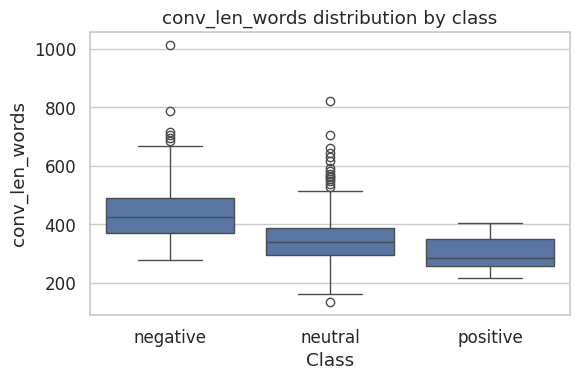

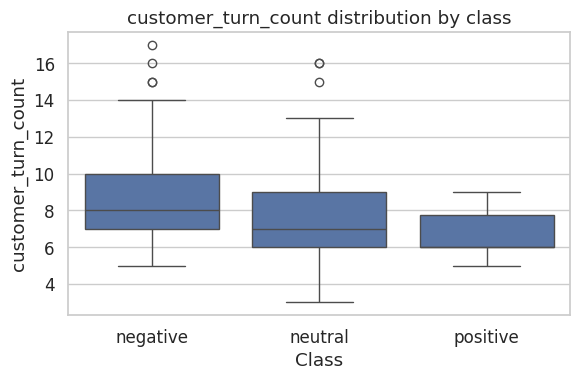

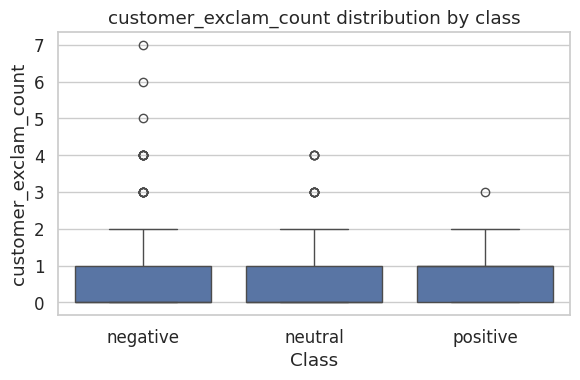

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set(style="whitegrid", font_scale=1.1)

label_map = {0: "negative", 1: "neutral", 2: "positive"}
plot_df = train_df_base.copy()
plot_df["label_name"] = plot_df["labels"].map(label_map)


features = ["conv_len_words", "customer_turn_count", "customer_exclam_count"]

for feature in features:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=plot_df, x="label_name", y=feature)

    plt.title(f"{feature} distribution by class")
    plt.xlabel("Class")
    plt.ylabel(feature)

    plt.tight_layout()
    plt.show()

In [10]:
features = ["conv_len_words", "customer_turn_count", "customer_exclam_count"]

summary_table = (
    plot_df
    .groupby("label_name")[features]
    .agg(["mean", "std", "median", "min", "max"])
    .round(2)
)

print(summary_table)

           conv_len_words                          customer_turn_count        \
                     mean    std median  min   max                mean   std   
label_name                                                                     
negative           435.58  94.07  424.0  277  1013                8.78  1.90   
neutral            347.85  83.94  341.0  134   821                7.58  1.83   
positive           301.79  57.47  285.5  217   405                6.71  1.33   

                          customer_exclam_count                       
           median min max                  mean   std median min max  
label_name                                                            
negative      8.0   5  17                  0.59  1.03    0.0   0   7  
neutral       7.0   3  16                  0.54  0.71    0.0   0   4  
positive      6.0   5   9                  0.93  0.92    1.0   0   3  


The distribution of the engineered numerical features shows that conversation length and customer interaction patterns differ across sentiment classes, with negative conversations tending to be longer and involving more customer turns. This indicates that these features capture behavioral signals. In contrast, the neutral and positive classes appear more similar in terms of length and interaction frequency; however, it is observed that some positive cases include exclamation marks, which may represent sentiment that is not explicitly reflected in the words themselves. This suggests that even these numerical features can provide additional nuance in the model adn were therefore included in the following experiments.

Oversampling with weighted cross entropy and numerical features


In [8]:
import os
import random
import re
import itertools
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import wandb

from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.utils.class_weight import compute_class_weight
from datasets import Dataset
from transformers import (
    RobertaTokenizer,
    RobertaModel,
    TrainingArguments,
    Trainer
)

SEED = 42
PROJECT_NAME = "DI725_Assignment_1"

# Seed
set_seed(SEED)

# Helpers
def normalize_label_column(df):
    if "labels" in df.columns:
        df = df.dropna(subset=["text", "labels"]).copy()
    elif "label" in df.columns:
        df = df.dropna(subset=["text", "label"]).copy()
        df = df.rename(columns={"label": "labels"})
    else:
        raise ValueError("Neither 'label' nor 'labels' column found.")
    return df

def extract_customer_segments(text):
    """
    Returns a list of customer utterances based on <cust> and <agent> markers.
    Assumes text contains these special tokens.
    """
    text = str(text)

    # Capture text after <cust> until next <cust>, <agent>, or end
    pattern = r"<cust>\s*(.*?)(?=(<cust>|<agent>|$))"
    matches = re.findall(pattern, text, flags=re.DOTALL | re.IGNORECASE)

    customer_segments = [m[0].strip() for m in matches if m[0].strip()]
    return customer_segments

def add_numerical_features(df):
    df = df.copy()

    df["conv_len_words"] = df["text"].astype(str).apply(
        lambda x: len(re.findall(r"\b\w+\b", x))
    )

    df["customer_turn_count"] = df["text"].astype(str).apply(
        lambda x: len(extract_customer_segments(x))
    )

    df["customer_exclam_count"] = df["text"].astype(str).apply(
        lambda x: sum(seg.count("!") for seg in extract_customer_segments(x))
    )

    return df

def oversample_smallest_class(train_df, label_col="labels", multiplier=4, seed=42):
    counts = train_df[label_col].value_counts()
    min_class = counts.idxmin()
    min_size = counts.min()
    max_size = counts.max()

    minority_df = train_df[train_df[label_col] == min_class]
    target_size = min(min_size * multiplier, max_size)

    upsampled_minority = minority_df.sample(
        n=target_size,
        replace=True,
        random_state=seed
    )

    train_df = pd.concat(
        [train_df[train_df[label_col] != min_class], upsampled_minority],
        axis=0
    ).sample(frac=1, random_state=seed).reset_index(drop=True)

    return train_df

def standardize_numeric_features(train_df, val_df, feature_cols):
    train_df = train_df.copy()
    val_df = val_df.copy()

    stats = {}
    for col in feature_cols:
        mean_val = train_df[col].mean()
        std_val = train_df[col].std()
        if std_val == 0 or pd.isna(std_val):
            std_val = 1.0

        train_df[col] = (train_df[col] - mean_val) / std_val
        val_df[col] = (val_df[col] - mean_val) / std_val

        stats[col] = {"mean": mean_val, "std": std_val}

    return train_df, val_df, stats

# Model
class RobertaHybridNumericClassifier(nn.Module):
    def __init__(self, model_name, num_labels, num_numeric_features):
        super().__init__()
        self.roberta = RobertaModel.from_pretrained(model_name)
        self.num_numeric_features = num_numeric_features

        text_hidden = self.roberta.config.hidden_size

        if num_numeric_features > 0:
            self.numeric_projection = nn.Sequential(
                nn.Linear(num_numeric_features, 32),
                nn.ReLU(),
                nn.Dropout(0.1)
            )
            combined_size = text_hidden + 32
        else:
            self.numeric_projection = None
            combined_size = text_hidden

        self.classifier = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, num_labels)
        )

    @property
    def device(self):
        return next(self.parameters()).device

    def forward(self, input_ids, attention_mask, numeric_features=None, labels=None, loss_weights=None):
        outputs = self.roberta(input_ids=input_ids, attention_mask=attention_mask)
        text_output = outputs.last_hidden_state[:, 0, :]

        if self.num_numeric_features > 0:
            numeric_repr = self.numeric_projection(numeric_features.float())
            final_input = torch.cat((text_output, numeric_repr), dim=1)
        else:
            final_input = text_output

        logits = self.classifier(final_input)

        loss = None
        if labels is not None:
            if loss_weights is not None:
                loss_fct = nn.CrossEntropyLoss(weight=loss_weights)
            else:
                loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits} if loss is not None else {"logits": logits}


class HybridNumericDataCollator:
    def __init__(self, tokenizer, numeric_feature_cols):
        self.tokenizer = tokenizer
        self.numeric_feature_cols = numeric_feature_cols

    def __call__(self, features):
        text_features = [
            {
                "input_ids": f["input_ids"],
                "attention_mask": f["attention_mask"]
            }
            for f in features
        ]

        batch = self.tokenizer.pad(
            text_features,
            padding=True,
            return_tensors="pt"
        )

        if len(self.numeric_feature_cols) > 0:
            batch["numeric_features"] = torch.tensor(
                [f["numeric_features"] for f in features],
                dtype=torch.float
            )

        batch["labels"] = torch.tensor(
            [f["labels"] for f in features],
            dtype=torch.long
        )

        return batch

class HybridNumericTrainer(Trainer):
    def __init__(self, loss_weights=None, use_numeric_features=True, **kwargs):
        super().__init__(**kwargs)
        self.loss_weights = loss_weights
        self.use_numeric_features = use_numeric_features

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        weights = self.loss_weights.to(model.device) if self.loss_weights is not None else None

        model_inputs = {
            "input_ids": inputs["input_ids"],
            "attention_mask": inputs["attention_mask"],
            "labels": inputs["labels"],
            "loss_weights": weights
        }

        if self.use_numeric_features:
            model_inputs["numeric_features"] = inputs["numeric_features"]

        outputs = model(**model_inputs)
        loss = outputs["loss"]

        return (loss, outputs) if return_outputs else loss


# Metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "f1_macro": f1_score(labels, preds, average="macro")
    }


# Tokenizer
tokenizer = RobertaTokenizer.from_pretrained("roberta-base")
tokenizer.add_tokens(["<cust>", "<agent>"])

def tokenize_with_numeric(examples, numeric_feature_cols):
    tokenized = tokenizer(examples["text"], truncation=False, add_special_tokens=False)

    input_ids = []
    attention_mask = []

    for ids in tokenized["input_ids"]:
        processed = ids[-510:] if len(ids) > 510 else ids
        combined = [tokenizer.bos_token_id] + processed + [tokenizer.eos_token_id]
        input_ids.append(combined)
        attention_mask.append([1] * len(combined))

    output = {
        "input_ids": input_ids,
        "attention_mask": attention_mask
    }

    if len(numeric_feature_cols) > 0:
        numeric_data = []
        for row_idx in range(len(examples["text"])):
            numeric_data.append([examples[col][row_idx] for col in numeric_feature_cols])
        output["numeric_features"] = numeric_data

    return output

# Data load
train_df_base = pd.read_csv("data/preprocessed/preprocessed_train.csv")
val_df_base = pd.read_csv("data/preprocessed/preprocessed_val.csv")

train_df_base = normalize_label_column(train_df_base)
val_df_base = normalize_label_column(val_df_base)

train_df_base["labels"] = train_df_base["labels"].astype(int)
val_df_base["labels"] = val_df_base["labels"].astype(int)

train_df_base = add_numerical_features(train_df_base)
val_df_base = add_numerical_features(val_df_base)

ALL_NUMERIC_FEATURES = [
    "conv_len_words",
    "customer_turn_count",
    "customer_exclam_count"
]

print("Sample engineered features:")
print(train_df_base[["text", "labels"] + ALL_NUMERIC_FEATURES].head(3))


# Experiment combinations
feature_sets = [
    ["conv_len_words"],
    ["customer_turn_count"],
    ["customer_exclam_count"],
    ["conv_len_words", "customer_turn_count"],
    ["conv_len_words", "customer_exclam_count"],
    ["customer_turn_count", "customer_exclam_count"],
    ["conv_len_words", "customer_turn_count", "customer_exclam_count"],
]

# Run experiments
all_results = []

for numeric_feature_cols in feature_sets:
    set_seed(SEED)
    torch.cuda.empty_cache()

    feature_tag = "_".join(numeric_feature_cols)
    experiment_name = f"hybrid-roberta-tail-oversample-weighted-numeric-{feature_tag}"

    print("\n" + "=" * 80)
    print(f"Running experiment: {experiment_name}")
    print(f"Numeric features: {numeric_feature_cols}")
    print("=" * 80)

    wandb.init(
        project=PROJECT_NAME,
        name=experiment_name,
        reinit=True,
        config={
            "learning_rate": 2e-5,
            "epochs": 5,
            "batch_size": 8,
            "sampling": "oversample_smallest_class_x4",
            "loss": "weighted_cross_entropy",
            "model_type": "hybrid_roberta_numeric",
            "truncation": "tail",
            "seed": SEED,
            "numeric_features": numeric_feature_cols
        }
    )


    train_df = train_df_base.copy()
    val_df = val_df_base.copy()

    # Class weights from original distribution before oversampling
    original_weights = compute_class_weight(
        class_weight="balanced",
        classes=np.unique(train_df["labels"]),
        y=train_df["labels"]
    )
    original_weights_tensor = torch.tensor(original_weights, dtype=torch.float)
    print(f"Original class weights: {original_weights}")

    # Oversample smallest class
    train_df = oversample_smallest_class(
        train_df,
        label_col="labels",
        multiplier=4,
        seed=SEED
    )

    print("Post-oversample distribution:")
    print(train_df["labels"].value_counts())

    # Standardize selected numeric features
    train_df, val_df, stats = standardize_numeric_features(
        train_df,
        val_df,
        numeric_feature_cols
    )

    # Convert to Dataset
    train_dataset = Dataset.from_pandas(train_df.reset_index(drop=True))
    val_dataset = Dataset.from_pandas(val_df.reset_index(drop=True))

    # Tokenize
    train_dataset = train_dataset.map(
        lambda examples: tokenize_with_numeric(examples, numeric_feature_cols),
        batched=True
    )
    val_dataset = val_dataset.map(
        lambda examples: tokenize_with_numeric(examples, numeric_feature_cols),
        batched=True
    )

    keep_cols = ["input_ids", "attention_mask", "labels"]
    if len(numeric_feature_cols) > 0:
        keep_cols.append("numeric_features")

    train_dataset = train_dataset.remove_columns(
        [c for c in train_dataset.column_names if c not in keep_cols]
    )
    val_dataset = val_dataset.remove_columns(
        [c for c in val_dataset.column_names if c not in keep_cols]
    )

    # Model
    model = RobertaHybridNumericClassifier(
        model_name="roberta-base",
        num_labels=3,
        num_numeric_features=len(numeric_feature_cols)
    )
    model.roberta.resize_token_embeddings(len(tokenizer))

    training_args = TrainingArguments(
        output_dir=f"./results_{feature_tag}",
        seed=SEED,
        data_seed=SEED,
        full_determinism=True,
        dataloader_num_workers=0,
        eval_strategy="epoch",
        save_strategy="epoch",
        logging_strategy="steps",
        logging_steps=10,
        logging_first_step=True,
        learning_rate=2e-5,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=8,
        num_train_epochs=5,
        weight_decay=0.01,
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        report_to="wandb",
        remove_unused_columns=False,
        fp16=torch.cuda.is_available()
    )

    trainer = HybridNumericTrainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=val_dataset,
        data_collator=HybridNumericDataCollator(tokenizer, numeric_feature_cols),
        compute_metrics=compute_metrics,
        loss_weights=original_weights_tensor,
        use_numeric_features=(len(numeric_feature_cols) > 0)
    )

    trainer.train()

    preds_output = trainer.predict(val_dataset)
    y_pred = np.argmax(preds_output.predictions, axis=1)

    report = classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"],
        output_dict=True
    )

    print(classification_report(
        preds_output.label_ids,
        y_pred,
        target_names=["negative", "neutral", "positive"]
    ))

    wandb.log({
        "final_accuracy": report["accuracy"],
        "final_f1_macro": report["macro avg"]["f1-score"]
    })

    all_results.append({
        "features": ", ".join(numeric_feature_cols),
        "accuracy": report["accuracy"],
        "f1_macro": report["macro avg"]["f1-score"]
    })

    wandb.finish()

# Summary
results_df = pd.DataFrame(all_results).sort_values("f1_macro", ascending=False).reset_index(drop=True)

print("\nOverall experiment summary:")
print(results_df)

Global seed set to: 42
Sample engineered features:
                                                text  labels  conv_len_words  \
0  <agent> Hello, thank you for contacting BrownB...       0             427   
1  <cust> Hi, I need help with returning a toy I ...       1             366   
2  <cust> Hello, I'm calling about my order for a...       0             500   

   customer_turn_count  customer_exclam_count  
0                    7                      0  
1                    9                      0  
2                   10                      0  
Global seed set to: 42

Running experiment: hybrid-roberta-tail-oversample-weighted-numeric-conv_len_words
Numeric features: ['conv_len_words']


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Original class weights: [ 0.79038855  0.59507313 18.4047619 ]
Post-oversample distribution:
labels
1    433
0    326
2     56
Name: count, dtype: int64


Map:   0%|          | 0/815 [00:00<?, ? examples/s]

Token indices sequence length is longer than the specified maximum sequence length for this model (694 > 512). Running this sequence through the model will result in indexing errors


...

RobertaModel LOAD REPORT from: roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
pooler.dense.bias               | MISSING    | 
pooler.dense.weight             | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.938364,0.732306,0.644330,0.522098
2,0.305988,0.586719,0.850515,0.573746
3,0.180089,0.576386,0.886598,0.708088
4,0.128275,0.534020,0.902062,0.704080
5,0.059091,0.655413,0.907216,0.721456


              precision    recall  f1-score   support

    negative       0.95      0.88      0.91        82
     neutral       0.90      0.94      0.92       109
    positive       0.33      0.33      0.33         3

    accuracy                           0.91       194
   macro avg       0.73      0.72      0.72       194
weighted avg       0.91      0.91      0.91       194



eval/accuracy,▁▆▇██
eval/f1_macro,▁▃█▇█
eval/loss,█▃▂▁▅
eval/runtime,▁▅▅█▃
eval/samples_per_second,█▄▄▁▆
eval/steps_per_second,█▄▄▁▆
final_accuracy,▁
final_f1_macro,▁
test/accuracy,▁
test/f1_macro,▁
+9,...



Overall experiment summary:
                                            features  accuracy  f1_macro
0         customer_turn_count, customer_exclam_count  0.902062  0.852173
1                                     conv_len_words  0.922680  0.839851
2                              customer_exclam_count  0.917526  0.780357
3                conv_len_words, customer_turn_count  0.912371  0.745552
4                                customer_turn_count  0.902062  0.738097
5              conv_len_words, customer_exclam_count  0.891753  0.730701
6  conv_len_words, customer_turn_count, customer_...  0.907216  0.721456


Oversampling with weighted loss, categorical features and numerical features.